# Alternative hydrological connectivity check

This notebook checks how mapped Tasmanian watercourses relate to DEM-derived flow accumulation and the Karst Atlas connectivity classes around Mole Creek. It is an exploratory spatial comparison: watercourse lines are rasterised to the DEM grid, then compared with cells in the top 5% of flow accumulation. The final map places the mapped watercourses over the Atlas connectivity raster.

The workflow uses the DEM and Atlas rasters prepared by the other project stages. It does not recalculate either raster.


In [1]:
from pathlib import Path
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from rasterio.features import rasterize, shapes
from shapely.geometry import box, shape

TARGET_CRS = "EPSG:7855"  # GDA2020 / MGA zone 55
FLOW_THRESHOLD = 166  # Existing 95th-percentile threshold for this DEM

data_path = Path(os.environ.get("AT3_DATA_DIR", "data"))
input_path = data_path / "Input_data"
output_path = data_path / "Output_data"
dem_path = output_path / "dem_mc_EPSG7855.tif"
flow_accumulation_path = output_path / "flow_accum_mc_EPSG7855.tif"
connectivity_path = output_path / "connectivity_atlas_mc_EPSG7855.tif"


## 1. Assemble mapped watercourses

Read the municipality Hydline files, retain features classified as `Watercourse`, check that each source has a CRS, and reproject each source to EPSG:7855 before merging. The merged features are saved to `Output_data/watercourses_tas_EPSG7855.gpkg` in the `Watercourse` layer and remain available here for clipping to the DEM footprint.


In [ ]:
# Read each municipality Hydline source, retain Watercourse features, and
# reproject each source only after confirming its CRS is defined.
hydline_root = input_path / "Hydline"
hydline_files = sorted(hydline_root.rglob("list_hydline_*.shp"))
if not hydline_files:
    raise FileNotFoundError(f"No hydline shapefiles found under {hydline_root}")

watercourse_frames = []
for path in hydline_files:
    features = gpd.read_file(path)
    if "HYDLNTY1" not in features.columns:
        continue
    watercourses_from_file = features.loc[features["HYDLNTY1"].eq("Watercourse")].copy()
    if watercourses_from_file.empty:
        continue
    if watercourses_from_file.crs is None:
        raise ValueError(f"Hydline source has no CRS; cannot safely reproject: {path}")
    watercourse_frames.append(watercourses_from_file.to_crs(TARGET_CRS))

if not watercourse_frames:
    raise ValueError("No Watercourse features were found in the hydline shapefiles")

watercourses = gpd.GeoDataFrame(
    pd.concat(watercourse_frames, ignore_index=True),
    geometry="geometry",
    crs=TARGET_CRS,
)
watercourse_gpkg_path = output_path / "watercourses_tas_EPSG7855.gpkg"
output_path.mkdir(parents=True, exist_ok=True)
watercourses.to_file(
    watercourse_gpkg_path,
    layer="Watercourse",
    driver="GPKG",
    index=False,
)
print(f"Hydline files read: {len(hydline_files)}")
print(f"Watercourse features merged: {len(watercourses):,}")
print(f"Saved CRS: {watercourses.crs}")
print(f"GeoPackage: {watercourse_gpkg_path}")


## 2. Clip to the DEM footprint

Load the merged Watercourse layer from the GeoPackage created in section 1, check its CRS, project it to the DEM coordinate system if needed, and clip it to the raster bounds. Using the raster bounds keeps the vector and raster extents tied to the same source.


In [ ]:
watercourse_gpkg_path = output_path / "watercourses_tas_EPSG7855.gpkg"
if not watercourse_gpkg_path.exists():
    raise FileNotFoundError(
        f"Watercourse GeoPackage not found: {watercourse_gpkg_path}. "
        "Run the section 1 assembly cell first."
    )
watercourses = gpd.read_file(watercourse_gpkg_path, layer="Watercourse")
if watercourses.crs is None:
    raise ValueError(f"The Watercourse GeoPackage layer has no CRS: {watercourse_gpkg_path}")

with rasterio.open(dem_path) as src:
    dem_bounds = src.bounds
    dem_crs = src.crs

if dem_crs is None:
    raise ValueError(f"The DEM has no CRS: {dem_path}")

watercourses_projected = watercourses.to_crs(dem_crs)
dem_extent = gpd.GeoDataFrame(
    geometry=[box(dem_bounds.left, dem_bounds.bottom, dem_bounds.right, dem_bounds.top)],
    crs=dem_crs,
)
watercourses_in_dem = gpd.clip(watercourses_projected, dem_extent)
print(f"Watercourse GeoPackage CRS: {watercourses.crs}")
print(f"DEM CRS: {dem_crs}")
print(f"Watercourse features within DEM bounds: {len(watercourses_in_dem):,}")


## 3. Load flow accumulation and inspect its spatial relationship to the lines

NoData cells are masked before plotting. The logarithmic colour scale makes both small and large accumulation values visible.


C:\Users\innoc\AppData\Local\Temp\ipykernel_27120\3800451103.py:16: RuntimeWarning: invalid value encountered in log1p
  log_flow = np.log1p(flow_accumulation)


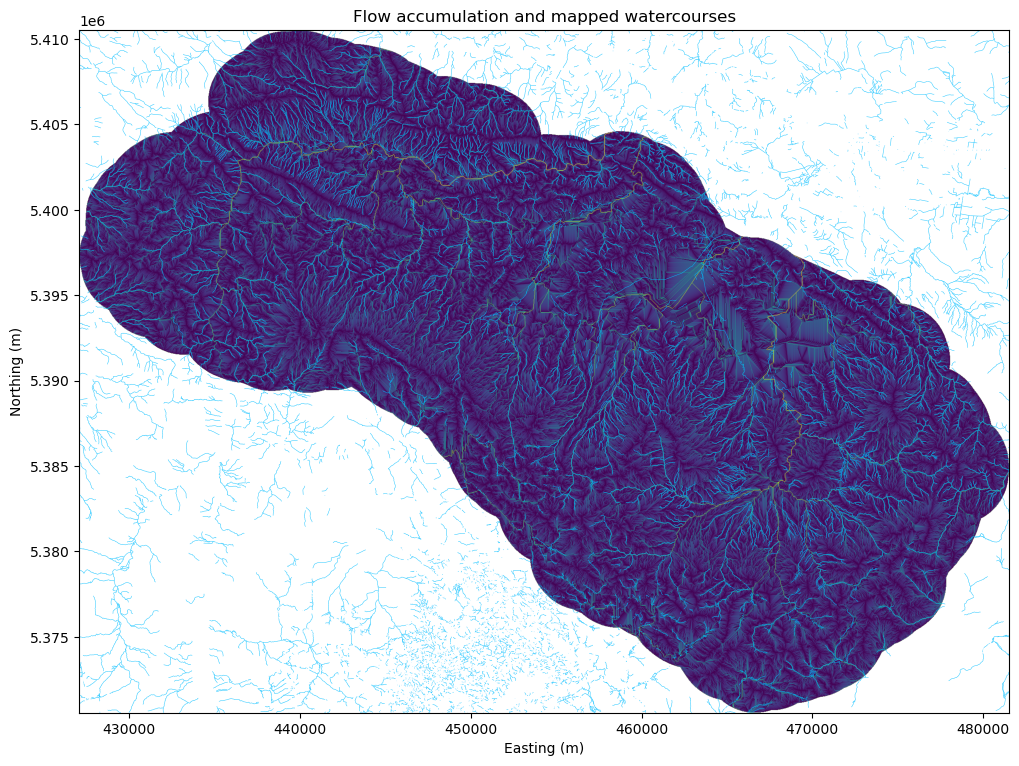

In [4]:
with rasterio.open(flow_accumulation_path) as src:
    flow_accumulation = src.read(1, masked=True)
    flow_transform = src.transform
    flow_crs = src.crs

if flow_crs != dem_crs:
    raise ValueError(f"Flow raster CRS {flow_crs} does not match DEM CRS {dem_crs}")

height, width = flow_accumulation.shape
flow_extent = (
    flow_transform.c,
    flow_transform.c + flow_transform.a * width,
    flow_transform.f + flow_transform.e * height,
    flow_transform.f,
)
log_flow = np.log1p(flow_accumulation)

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(log_flow, extent=flow_extent, origin="upper", cmap="viridis")
watercourses_in_dem.plot(ax=ax, linewidth=0.4, color="deepskyblue", alpha=0.75)
ax.set(title="Flow accumulation and mapped watercourses", xlabel="Easting (m)", ylabel="Northing (m)")
plt.show()


## 4. Restrict lines to valid DEM cells

The rectangular raster footprint can include NoData areas. Convert the DEM's valid-data mask to polygons and clip the mapped lines to that valid area before comparing them with raster cells.


In [5]:
with rasterio.open(dem_path) as src:
    dem = src.read(1, masked=True)
    dem_transform = src.transform

valid_mask = ~np.ma.getmaskarray(dem)
valid_shapes = shapes(
    valid_mask.astype("uint8"),
    mask=valid_mask,
    transform=dem_transform,
)
valid_polygons = [shape(geometry) for geometry, value in valid_shapes if value == 1]
if not valid_polygons:
    raise ValueError("The DEM contains no valid cells")

valid_dem_area = gpd.GeoDataFrame(geometry=valid_polygons, crs=dem_crs).dissolve()
watercourses_valid = gpd.clip(watercourses_in_dem, valid_dem_area)
print(f"Watercourse features within valid DEM cells: {len(watercourses_valid):,}")


Watercourse features within valid DEM cells: 6,886


## 5. Identify high-flow cells

The threshold of 166 flow-accumulation cells is the existing 95th-percentile threshold for this DEM. This selects approximately 5% of valid cells; it is used here as a drainage-channel proxy, not as a calibrated hydrological boundary.


In [6]:
high_flow = (flow_accumulation >= FLOW_THRESHOLD).filled(False)
valid_cell_count = int((~np.ma.getmaskarray(flow_accumulation)).sum())
high_flow_count = int(high_flow.sum())
print(f"Flow threshold: {FLOW_THRESHOLD} cells")
print(f"High-flow cells: {high_flow_count:,}")
print(f"Share of valid DEM cells: {100 * high_flow_count / valid_cell_count:.2f}%")


Flow threshold: 166 cells
High-flow cells: 92,468
Share of valid DEM cells: 5.00%


### Map the high-flow proxy

This overlay provides a visual check of whether mapped watercourses follow the cells selected by the flow threshold.


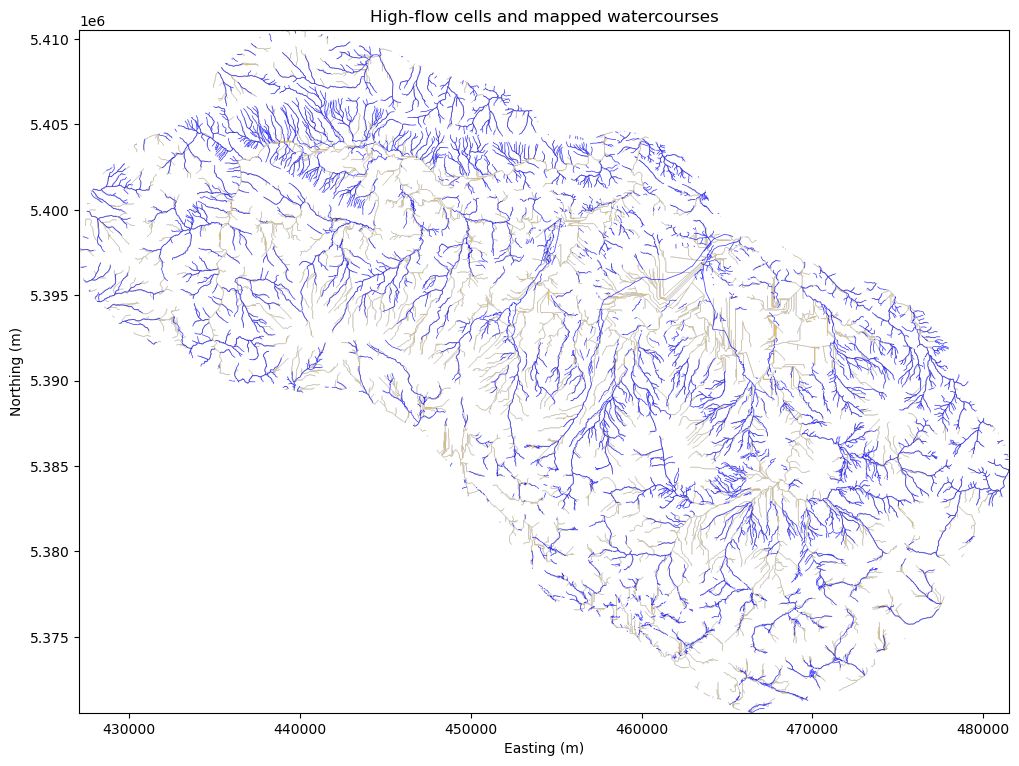

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(
    np.ma.masked_where(~high_flow, high_flow),
    extent=flow_extent,
    origin="upper",
    cmap=ListedColormap(["#f2a900"]),
    alpha=0.7,
)
watercourses_valid.plot(ax=ax, linewidth=0.5, color="blue", alpha=0.8)
ax.set(title="High-flow cells and mapped watercourses", xlabel="Easting (m)", ylabel="Northing (m)")
plt.show()


## 6. Compare watercourse cells with the high-flow proxy

Rasterise the valid watercourse lines onto the flow-accumulation grid. The reported percentage is the share of watercourse cells that also meet the high-flow threshold. Since line rasterisation and the flow threshold represent different spatial features, treat this as a simple overlap measure rather than an accuracy statistic.


In [8]:
watercourse_raster = rasterize(
    ((geometry, 1) for geometry in watercourses_valid.geometry if geometry is not None and not geometry.is_empty),
    out_shape=flow_accumulation.shape,
    transform=flow_transform,
    fill=0,
    dtype="uint8",
)
watercourse_cells = watercourse_raster == 1
matching_cells = watercourse_cells & high_flow
watercourse_cell_count = int(watercourse_cells.sum())
match_count = int(matching_cells.sum())
match_percentage = 100 * match_count / watercourse_cell_count if watercourse_cell_count else 0.0

print(f"Watercourse cells: {watercourse_cell_count:,}")
print(f"Watercourse cells meeting high-flow threshold: {match_count:,}")
print(f"Share meeting high-flow threshold: {match_percentage:.2f}%")


Watercourse cells: 86,503
Watercourse cells meeting high-flow threshold: 22,346
Share meeting high-flow threshold: 25.83%


## 7. Overlay mapped watercourses on Atlas connectivity

The final map shows the existing Karst Atlas connectivity classes and the mapped watercourses within valid DEM coverage. The Atlas classes are categorical: 0 is no connectivity, followed by low, moderate, and high connectivity.


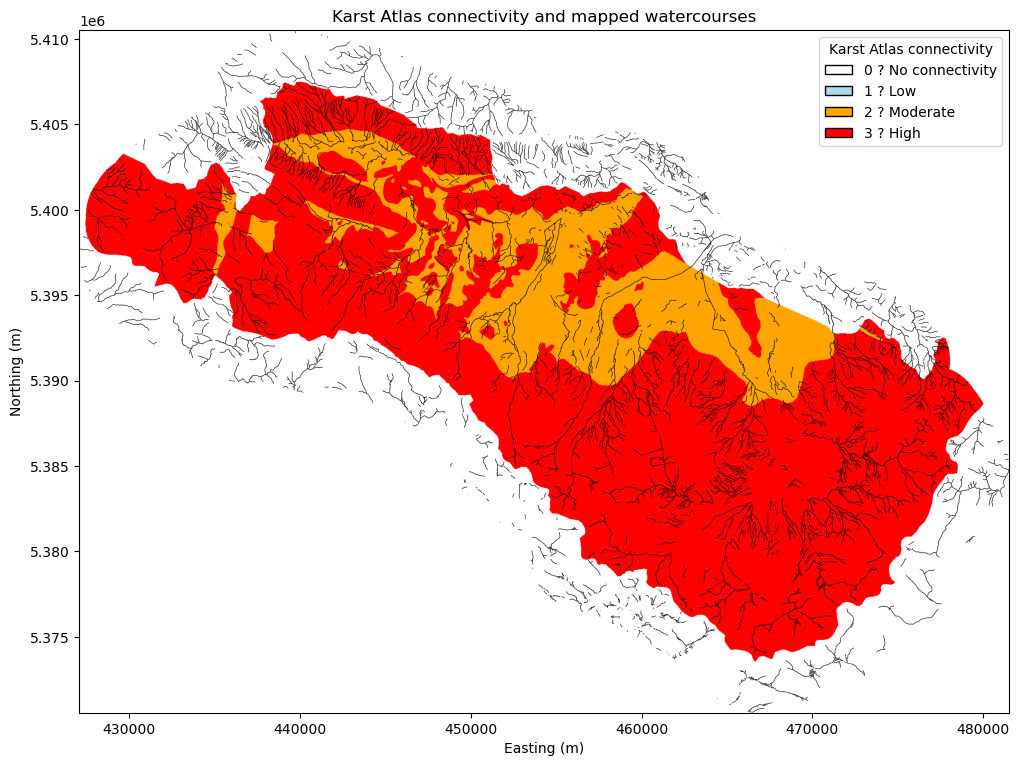

In [9]:
with rasterio.open(connectivity_path) as src:
    connectivity = src.read(1, masked=True)
    connectivity_transform = src.transform
    connectivity_crs = src.crs

if connectivity_crs != dem_crs:
    raise ValueError(
        f"Connectivity raster CRS {connectivity_crs} does not match DEM CRS {dem_crs}"
    )
if connectivity.shape != flow_accumulation.shape or connectivity_transform != flow_transform:
    raise ValueError("Connectivity and flow-accumulation rasters are not aligned")

connectivity_cmap = ListedColormap(["white", "lightblue", "orange", "red"])
legend_items = [
    Patch(facecolor="white", edgecolor="black", label="0 ? No connectivity"),
    Patch(facecolor="lightblue", edgecolor="black", label="1 ? Low"),
    Patch(facecolor="orange", edgecolor="black", label="2 ? Moderate"),
    Patch(facecolor="red", edgecolor="black", label="3 ? High"),
]

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(
    connectivity,
    extent=flow_extent,
    origin="upper",
    cmap=connectivity_cmap,
    vmin=0,
    vmax=3,
)
watercourses_valid.plot(ax=ax, linewidth=0.5, color="black", alpha=0.8)
ax.legend(handles=legend_items, title="Karst Atlas connectivity", loc="upper right")
ax.set(title="Karst Atlas connectivity and mapped watercourses", xlabel="Easting (m)", ylabel="Northing (m)")
plt.show()


## Interpretation

The overlap percentage describes how often mapped watercourse cells coincide with the DEM high-flow proxy. It should be read alongside the maps: raster resolution, line width, DEM conditioning, and the chosen threshold all affect the overlap. The Atlas overlay provides spatial context but does not imply that every mapped watercourse has the same connection to karst.


## 8. Map substantial depression fill areas

Compare the original DEM with the existing `dem_mc_filled.tif`. Fill depth is the elevation difference `filled DEM - original DEM`; cells raised by at least 1 m and 5 m are grouped using 8-neighbour connectivity. The plots use the original DEM as the background and the DEM's own extent and CRS. Karst polygon outlines are added when the existing Stage 2 GeoPackage is available.

For each threshold, the notebook also creates a companion map with the already clipped `watercourses_valid` layer when that GeoDataFrame is present in the current notebook session. This section does not reload or reprocess the watercourse data, and it does not write raster outputs.


Fill depth >= 1 m: 45 connected groups; 55,990 cells (3,499.4 ha)
  Five largest group areas (ha): [2256.7, 351.8, 312.1, 180.0, 101.4]
Fill depth >= 5 m: 25 connected groups; 47,859 cells (2,991.2 ha)
  Five largest group areas (ha): [2032.4, 335.1, 277.9, 91.4, 86.0]


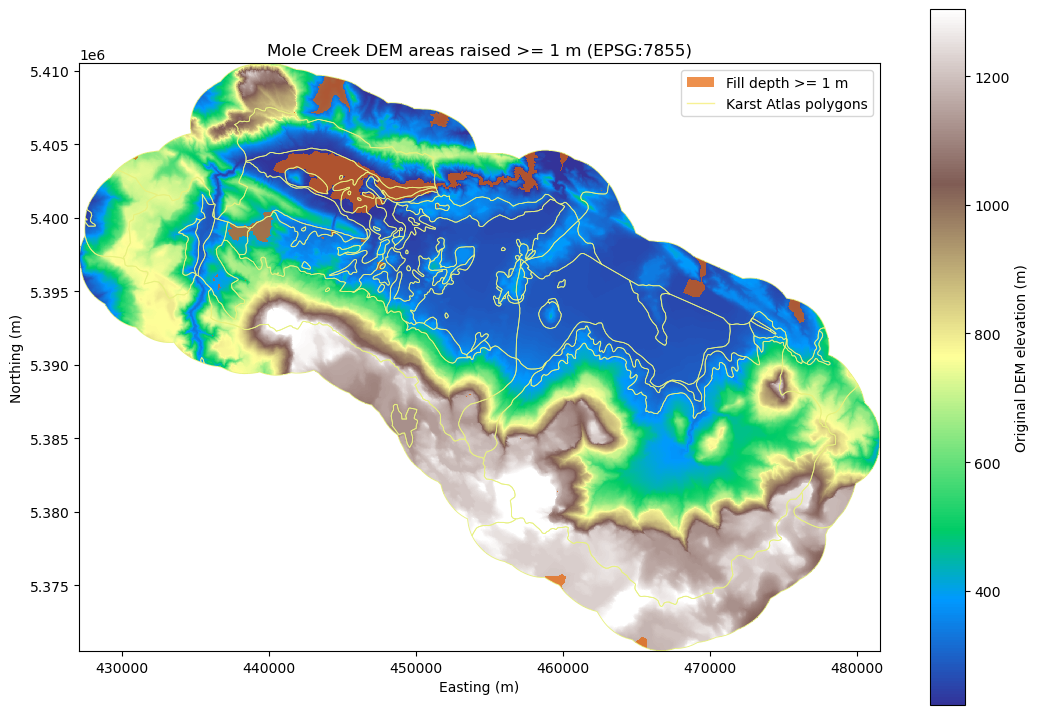

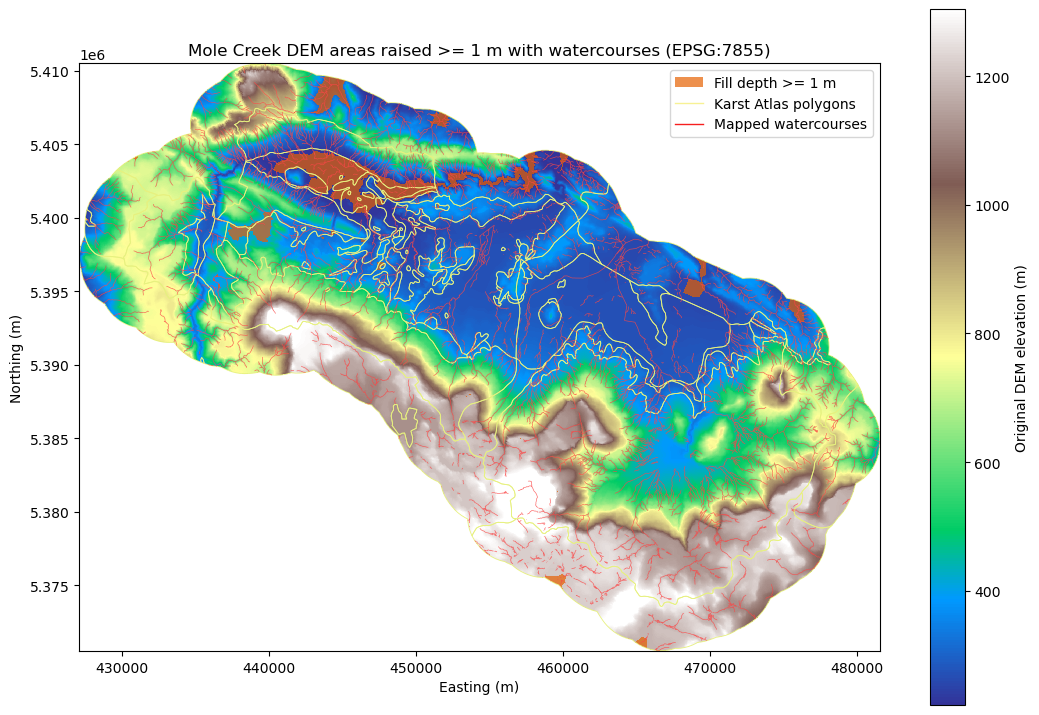

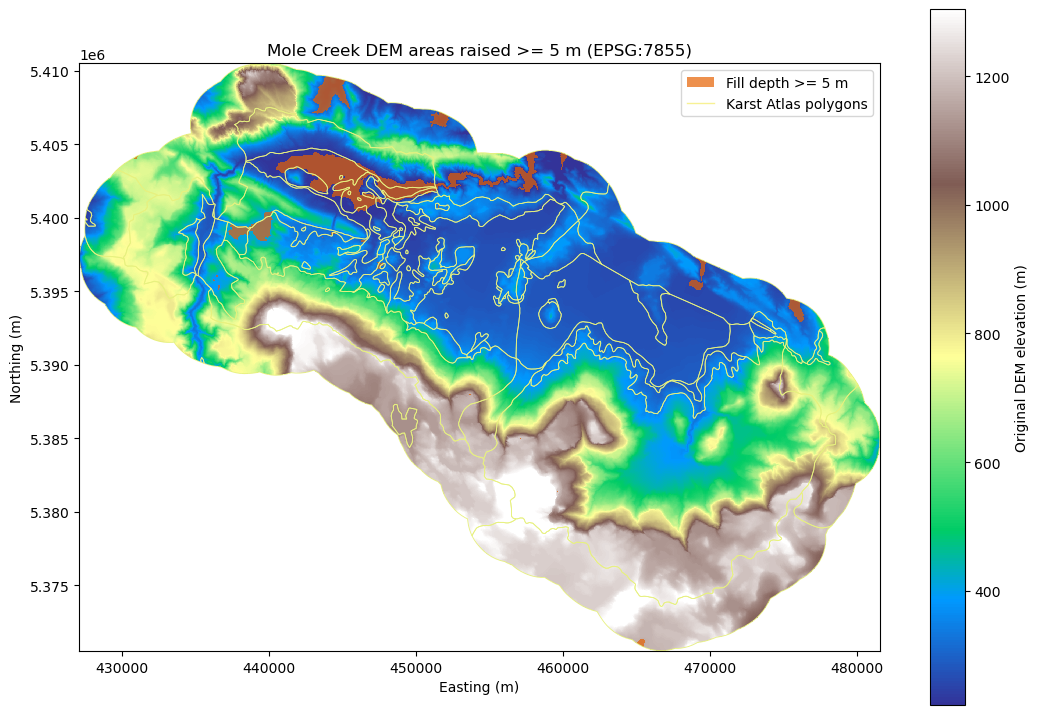

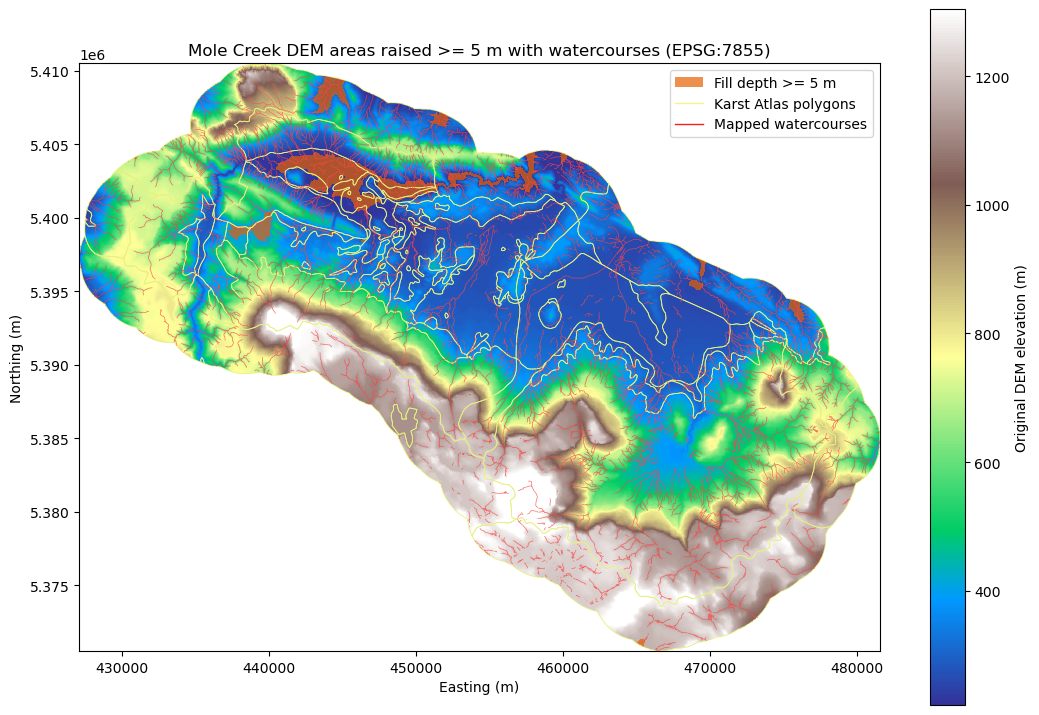

In [13]:
from scipy import ndimage
from matplotlib.lines import Line2D

# Read the existing rasters; do not alter or write either one.
with rasterio.open(dem_path) as src:
    original_dem = src.read(1, masked=True)
    dem_transform = src.transform
    dem_crs = src.crs
    dem_height, dem_width = src.height, src.width

with rasterio.open(output_path / "dem_mc_filled.tif") as src:
    filled_dem = src.read(1, masked=True)
    filled_transform = src.transform
    filled_crs = src.crs

if original_dem.shape != filled_dem.shape:
    raise ValueError("Original and filled DEMs have different dimensions")
if dem_transform != filled_transform or dem_crs != filled_crs:
    raise ValueError("Original and filled DEMs are not aligned")

# Calculate the requested difference only where both rasters have valid data.
valid_dem = ~(np.ma.getmaskarray(original_dem) | np.ma.getmaskarray(filled_dem))
fill_depth = np.full(original_dem.shape, np.nan, dtype="float32")
fill_depth[valid_dem] = (
    filled_dem.data[valid_dem] - original_dem.data[valid_dem]
)

thresholds = (1.0, 5.0)
threshold_masks = {threshold: valid_dem & (fill_depth >= threshold) for threshold in thresholds}
neighbor_structure = np.ones((3, 3), dtype="uint8")  # 8-connected groups
cell_area_m2 = abs(dem_transform.a * dem_transform.e)

# Label each group and report its size so the map can be related to components.
depression_groups = {}
for threshold, mask in threshold_masks.items():
    labels, group_count = ndimage.label(mask, structure=neighbor_structure)
    depression_groups[threshold] = labels
    group_sizes_ha = np.bincount(labels.ravel())[1:] * cell_area_m2 / 10_000
    largest_groups = np.sort(group_sizes_ha)[::-1][:5]
    print(
        f"Fill depth >= {threshold:g} m: {group_count:,} connected groups; "
        f"{int(mask.sum()):,} cells ({mask.sum() * cell_area_m2 / 10_000:,.1f} ha)"
    )
    print(f"  Five largest group areas (ha): {largest_groups.round(1).tolist()}")

# Load the existing Stage 2 karst polygons for spatial context, if available.
karst_path = output_path / "karst_mc_susceptibility_EPSG7855.gpkg"
if karst_path.exists():
    karst_polygons = gpd.read_file(karst_path)
    if karst_polygons.crs != dem_crs:
        karst_polygons = karst_polygons.to_crs(dem_crs)
    karst_polygons = karst_polygons[
        karst_polygons.geom_type.isin(["Polygon", "MultiPolygon"])
    ].copy()
else:
    karst_polygons = None
    print(f"Karst polygon layer not found: {karst_path}")

left, bottom, right, top = rasterio.transform.array_bounds(
    dem_height, dem_width, dem_transform
)
dem_extent = (left, right, bottom, top)
valid_elevations = original_dem.data[valid_dem]
dem_vmin, dem_vmax = np.percentile(valid_elevations, [2, 98])

# Reuse the clipped watercourse layer created earlier in this notebook, if present.
watercourses_for_map = globals().get("watercourses_valid")
if watercourses_for_map is not None and watercourses_for_map.crs != dem_crs:
    raise ValueError("The existing watercourses_valid layer is not in the DEM CRS")


def plot_fill_depth_map(threshold, include_watercourses=False):
    """Show one fill-depth mask over the original DEM."""
    fig, ax = plt.subplots(figsize=(11, 9))
    background = np.ma.masked_where(~valid_dem, original_dem.data)
    image = ax.imshow(
        background,
        extent=dem_extent,
        origin="upper",
        cmap="terrain",
        vmin=dem_vmin,
        vmax=dem_vmax,
        interpolation="nearest",
    )
    overlay = np.ma.masked_where(
        ~threshold_masks[threshold],
        np.ones(threshold_masks[threshold].shape),
    )
    ax.imshow(
        overlay,
        extent=dem_extent,
        origin="upper",
        cmap=ListedColormap(["#e66101"]),
        alpha=0.7,
        interpolation="nearest",
    )

    legend_handles = [
        Patch(facecolor="#e66101", alpha=0.7, label=f"Fill depth >= {threshold:g} m")
    ]
    if karst_polygons is not None and not karst_polygons.empty:
        karst_polygons.boundary.plot(ax=ax, color="#e7f17f", linewidth=0.6)
        legend_handles.append(
            Line2D([0], [0], color="#f7f194", linewidth=1, label="Karst Atlas polygons")
        )
    if include_watercourses:
        watercourses_for_map.plot(ax=ax, color="#fc4747", linewidth=0.45, alpha=0.85)
        legend_handles.append(
            Line2D([0], [0], color="#f61f1f", linewidth=1, label="Mapped watercourses")
        )

    suffix = " with watercourses" if include_watercourses else ""
    ax.set_title(f"Mole Creek DEM areas raised >= {threshold:g} m{suffix} ({dem_crs})")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(handles=legend_handles, loc="upper right")
    fig.colorbar(image, ax=ax, label="Original DEM elevation (m)", shrink=0.8)
    plt.tight_layout()
    plt.show()


for threshold in thresholds:
    plot_fill_depth_map(threshold)
    if watercourses_for_map is not None and not watercourses_for_map.empty:
        plot_fill_depth_map(threshold, include_watercourses=True)
